# South African Retail Sales Analysis

## Project Overview

This project analyses retail transaction data to identify patterns in product
performance, customer purchasing behaviour, sales channels, pricing, discounts,
and revenue.

The analysis combines SQL and Python. SQL is used to answer core business
questions and perform grouped and window-based analysis, while pandas and
Matplotlib are used for deeper exploratory analysis and visualization.

### Objectives

The project investigates:

- Which products customers purchase most frequently
- How discounts relate to purchasing behaviour
- Whether unit price is associated with quantity purchased
- Which products perform best across cities
- Which product categories generate the strongest sales performance
- How revenue changes over time
- How customer and sales-channel behaviour differs
- How discount levels relate to sales volume and revenue per order

  ## Dataset Overview

The dataset contains retail transactions with information on orders,
customers, products, categories, quantities, prices, discounts, cities,
sales channels, and order dates.

Initial data-quality checks identified duplicate records, missing values,
inconsistent text formatting, invalid quantity values, currency-formatted
prices, and invalid date entries. These issues were cleaned before analysis.

In [1]:
# import all the modules to be used
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import sqlite3

## Load CSV

In [2]:
# Load the dataset using a repository-relative path
from pathlib import Path

path = Path("../data/retail_sales_project_2.csv")
df = pd.read_csv(path)
df.head()


,Order_ID,Order_Date,Customer_ID,Customer_Name,Product,Category,Quantity,Unit_Price,Discount,City,Sales_Channel
0,ORD-100001,2025-11-25,CUST-1028,Naledi Mahlangu,Smartphone,Electronics,3,6908.72,5,Pretoria,Store
1,ORD-100002,2025-06-01,CUST-1289,Ayanda Molefe,Sneakers,Clothing,2,1066.24,0,Pretoria,Mobile App
2,ORD-100003,2025-12-21,CUST-1140,Tshepo Mokoena,Jeans,Clothing,3,707.61,0,Cape Town,Store
3,ORD-100004,2025-07-28,CUST-1091,Zanele Molefe,Desk,Furniture,3,3859.95,15,Durban,Online
4,ORD-100005,2025-05-21,CUST-1008,Karabo Mokoena,Desk,Furniture,1,3677.92,15,Durban,Online


## Understand the data 

In [3]:
# find the shape of the data
print(df.shape)

(3510, 11)


In [4]:
# find the names of the columns
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Product',
       'Category', 'Quantity', 'Unit_Price', 'Discount', 'City',
       'Sales_Channel'],
      dtype='object')

In [5]:
# Find the data types of the columns
df.dtypes

Order_ID         object
Order_Date       object
Customer_ID      object
Customer_Name    object
Product          object
Category         object
Quantity         object
Unit_Price       object
Discount          int64
City             object
Sales_Channel    object
dtype: object

In [6]:
# Find the columns with null entries and how many of them are there 
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name     0
Product           0
Category          0
Quantity          0
Unit_Price        0
Discount          0
City             20
Sales_Channel     0
dtype: int64

In [7]:
# Find duplicated data
df[df.duplicated()]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Product,Category,Quantity,Unit_Price,Discount,City,Sales_Channel
3500,ORD-100752,2025-05-31,CUST-1174,Naledi Molefe,Tablet,Electronics,2,4570.07,0,Pretoria,Online
3501,ORD-101415,2025-09-06,CUST-1350,Sipho Mahlangu,T-Shirt,Clothing,1,322.74,0,Pretoria,Mobile App
3502,ORD-102435,2025-06-03,CUST-1378,Thabo Khumalo,Desk,Furniture,1,3420.76,0,Gqeberha,Store
3503,ORD-100706,2025-05-14,CUST-1364,Anele Mahlangu,T-Shirt,Clothing,1,323.97,10,Johannesburg,Store
3504,ORD-103044,2025-11-03,CUST-1268,Tshepo Nkosi,Bookshelf,Furniture,1,1976.23,0,Pretoria,Online
3505,ORD-102654,not available,CUST-1152,Lebo Khumalo,Office Chair,Furniture,1,2734.27,10,Gqeberha,Store
3506,ORD-103360,2025-07-12,CUST-1370,Thabo Mthembu,Bookshelf,Furniture,1,1777.71,0,Bloemfontein,Online
3507,ORD-101445,2025-09-30,CUST-1017,Anele Mokoena,Tablet,Electronics,1,4643.67,5,Bloemfontein,Store
3508,ORD-101569,2025-01-15,CUST-1016,Zanele Khumalo,Microwave,Appliances,5,2303.45,0,Bloemfontein,Mobile App
3509,ORD-101448,2025-02-25,CUST-1234,Sipho Mokoena,Kettle,Appliances,3,616.98,0,Johannesburg,Store


In [8]:
order_ID = df[df["Order_ID"].duplicated()]["Order_ID"]
df[df["Order_ID"].isin(order_ID)]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Product,Category,Quantity,Unit_Price,Discount,City,Sales_Channel
705,ORD-100706,2025-05-14,CUST-1364,Anele Mahlangu,T-Shirt,Clothing,1,323.97,10,Johannesburg,Store
751,ORD-100752,2025-05-31,CUST-1174,Naledi Molefe,Tablet,Electronics,2,4570.07,0,Pretoria,Online
1414,ORD-101415,2025-09-06,CUST-1350,Sipho Mahlangu,T-Shirt,Clothing,1,322.74,0,Pretoria,Mobile App
1444,ORD-101445,2025-09-30,CUST-1017,Anele Mokoena,Tablet,Electronics,1,4643.67,5,Bloemfontein,Store
1447,ORD-101448,2025-02-25,CUST-1234,Sipho Mokoena,Kettle,Appliances,3,616.98,0,Johannesburg,Store
1568,ORD-101569,2025-01-15,CUST-1016,Zanele Khumalo,Microwave,Appliances,5,2303.45,0,Bloemfontein,Mobile App
2434,ORD-102435,2025-06-03,CUST-1378,Thabo Khumalo,Desk,Furniture,1,3420.76,0,Gqeberha,Store
2653,ORD-102654,not available,CUST-1152,Lebo Khumalo,Office Chair,Furniture,1,2734.27,10,Gqeberha,Store
3043,ORD-103044,2025-11-03,CUST-1268,Tshepo Nkosi,Bookshelf,Furniture,1,1976.23,0,Pretoria,Online
3359,ORD-103360,2025-07-12,CUST-1370,Thabo Mthembu,Bookshelf,Furniture,1,1777.71,0,Bloemfontein,Online


From what we are seeing the order ID has only these duplication problems

In [9]:
df["Quantity"].unique()

array(['3', '2', '1', '5', '4', '6', '?'], dtype=object)

Quantity has ? character which makes the whole column an object type

In [10]:
unique_bad_values = df[pd.to_numeric(df["Unit_Price"],errors="coerce").isna()]["Unit_Price"].unique()
unique_bad_values

array(['R13156.2', 'R644.48', 'R7251.19', 'R3388.87', 'R1223.39',
       'R1789.72', 'R1199.24', 'R897.53', 'R1323.62', 'R7282.67',
       'R7390.98', 'R648.92', 'R1113.97', 'R2738.52'], dtype=object)

R in front of the values causes the whole column to be an object

In [11]:
unique_bad_values = df[pd.to_datetime(df["Order_Date"],errors="coerce").isna()]["Order_Date"].unique()
unique_bad_values

array(['not available'], dtype=object)

Only not available is the wrong value in Order_Date column

In [12]:
df["Product"].unique()

array(['Smartphone', 'Sneakers', 'Jeans', 'Desk', 'Coffee Maker',
       'Jacket', 'Headphones', 'Bookshelf', 'Kettle', 'Office Chair',
       'Tablet', 'Microwave', 'T-Shirt', 'Laptop', 'Monitor',
       'coffee maker', 'office chair', 't-shirt', 'laptop', 'kettle',
       'smartphone', 'jeans', 'headphones', 'bookshelf', 'monitor'],
      dtype=object)

Product contains inconsistent capitalization, creating duplicate categorical labels for the same products.

In [13]:
df["Category"].unique()

array(['Electronics', 'Clothing', 'Furniture', 'Appliances'], dtype=object)

In [14]:
df["City"].unique()

array(['Pretoria', 'Cape Town', 'Durban', 'Bloemfontein', 'Gqeberha',
       'Johannesburg', nan], dtype=object)

In [15]:
df["Sales_Channel"].unique()

array(['Store', 'Mobile App', 'Online', 'mobile app', 'store', 'online'],
      dtype=object)

## Data Cleaning

The initial assessment identified several data-quality issues:

- Duplicate transaction records
- Invalid `?` values in `Quantity`
- Currency symbols in `Unit_Price`
- Invalid `not available` entries in `Order_Date`
- Inconsistent capitalization in `Product`
- Inconsistent capitalization in `Sales_Channel`
- Missing values in `Quantity`, `Order_Date`, and `City`

Invalid values were converted to appropriate missing values rather than dropping entire records where the remaining fields could still contribute to other analyses. Duplicate rows were removed to prevent double-counting.


In [16]:
df["Quantity"] = df["Quantity"].replace("?","")
df["Quantity"] = pd.to_numeric(df["Quantity"],errors = "coerce")
df["Quantity"].unique()

array([ 3.,  2.,  1.,  5.,  4.,  6., nan])

In [17]:
df["Unit_Price"] = df["Unit_Price"].str.replace("R","")
df["Unit_Price"] = pd.to_numeric(df["Unit_Price"],errors = "coerce")
df["Unit_Price"].unique()

array([6908.72, 1066.24,  707.61, ..., 1846.11, 6983.57, 3781.66])

In [18]:
df["Order_Date"] = df["Order_Date"].replace("not available",np.nan)
df["Order_Date"] = pd.to_datetime(df["Order_Date"],errors = "coerce")
unique_bad_values = df[pd.to_datetime(df["Order_Date"],errors="coerce").isna()]["Order_Date"].unique()
unique_bad_values

<DatetimeArray>
['NaT']
Length: 1, dtype: datetime64[ns]

In [19]:
df[["Quantity","Unit_Price","Order_Date"]].dtypes

Quantity             float64
Unit_Price           float64
Order_Date    datetime64[ns]
dtype: object

In [20]:
df[["Quantity","Unit_Price","Order_Date"]].isnull().sum()

Quantity      18
Unit_Price     0
Order_Date     9
dtype: int64

In [21]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Product,Category,Quantity,Unit_Price,Discount,City,Sales_Channel
0,ORD-100001,2025-11-25,CUST-1028,Naledi Mahlangu,Smartphone,Electronics,3.0,6908.72,5,Pretoria,Store
1,ORD-100002,2025-06-01,CUST-1289,Ayanda Molefe,Sneakers,Clothing,2.0,1066.24,0,Pretoria,Mobile App
2,ORD-100003,2025-12-21,CUST-1140,Tshepo Mokoena,Jeans,Clothing,3.0,707.61,0,Cape Town,Store
3,ORD-100004,2025-07-28,CUST-1091,Zanele Molefe,Desk,Furniture,3.0,3859.95,15,Durban,Online
4,ORD-100005,2025-05-21,CUST-1008,Karabo Mokoena,Desk,Furniture,1.0,3677.92,15,Durban,Online


In [22]:
df[df["Quantity"].isnull()]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Product,Category,Quantity,Unit_Price,Discount,City,Sales_Channel
204,ORD-100205,2025-01-02,CUST-1426,Zanele Nkosi,Desk,Furniture,NaN,3326.86,20,Cape Town,Mobile App
226,ORD-100227,2025-01-06,CUST-1050,Naledi Mahlangu,Coffee Maker,Appliances,NaN,1417.70,0,Gqeberha,Store
244,ORD-100245,2025-09-23,CUST-1109,Thabo Nkosi,Jeans,Clothing,NaN,701.12,20,Gqeberha,Mobile App
520,ORD-100521,2025-02-25,CUST-1060,Sipho Dlamini,Office Chair,Furniture,NaN,2679.51,15,Cape Town,Store
578,ORD-100579,2025-08-15,CUST-1112,Naledi Mahlangu,Microwave,Appliances,NaN,2229.87,5,Gqeberha,Store
1421,ORD-101422,2025-09-13,CUST-1393,Zanele Dlamini,Kettle,Appliances,NaN,672.85,0,Johannesburg,Store
1598,ORD-101599,2025-04-20,CUST-1423,Karabo Ndlovu,Coffee Maker,Appliances,NaN,1332.68,0,Johannesburg,Online
1686,ORD-101687,2025-01-31,CUST-1389,Naledi Dlamini,Desk,Furniture,NaN,3805.63,20,Cape Town,Store
1854,ORD-101855,2025-07-27,CUST-1353,Lerato Khumalo,Smartphone,Electronics,NaN,7730.14,0,Durban,Store
2040,ORD-102041,2025-09-25,CUST-1128,Zanele Mahlangu,Monitor,Electronics,NaN,2975.41,5,Johannesburg,Store


In [23]:
df[df["City"].isnull()]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Product,Category,Quantity,Unit_Price,Discount,City,Sales_Channel
108,ORD-100109,2025-04-13,CUST-1278,Naledi Mahlangu,Bookshelf,Furniture,1.0,1893.72,5,NaN,Mobile App
336,ORD-100337,2025-12-20,CUST-1089,Ayanda Mahlangu,Kettle,Appliances,1.0,646.31,10,NaN,Mobile App
684,ORD-100685,2025-07-07,CUST-1026,Naledi Mthembu,Tablet,Electronics,3.0,4518.69,0,NaN,Mobile App
1072,ORD-101073,2025-08-28,CUST-1223,Lerato Nkosi,Sneakers,Clothing,3.0,1141.12,20,NaN,Online
1094,ORD-101095,2025-05-05,CUST-1278,Naledi Mahlangu,Monitor,Electronics,1.0,3355.75,0,NaN,Mobile App
1217,ORD-101218,2025-12-01,CUST-1446,Ayanda Molefe,Jacket,Clothing,3.0,1326.21,15,NaN,Mobile App
1357,ORD-101358,2025-08-27,CUST-1285,Thabo Khumalo,Tablet,Electronics,4.0,5000.13,0,NaN,Online
1720,ORD-101721,2025-09-17,CUST-1137,Anele Mahlangu,Smartphone,Electronics,2.0,6927.95,15,NaN,Store
2202,ORD-102203,2025-05-04,CUST-1125,Tshepo Mahlangu,Laptop,Electronics,1.0,12495.38,5,NaN,Store
2229,ORD-102230,2025-04-28,CUST-1187,Thabo Mahlangu,Kettle,Appliances,2.0,607.83,20,NaN,Mobile App


In [24]:
df = df.drop_duplicates()

Remove duplicates so that they do not inflate data

In [25]:
df[df.duplicated()]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Product,Category,Quantity,Unit_Price,Discount,City,Sales_Channel


In [26]:
df.shape

(3500, 11)

In [27]:
df["Product"] = df["Product"].str.capitalize()

In [28]:
df["Sales_Channel"] = df["Sales_Channel"].str.capitalize()

In [29]:
df["Sales_Channel"].unique()

array(['Store', 'Mobile app', 'Online'], dtype=object)

In [30]:
df["Product"].unique()

array(['Smartphone', 'Sneakers', 'Jeans', 'Desk', 'Coffee maker',
       'Jacket', 'Headphones', 'Bookshelf', 'Kettle', 'Office chair',
       'Tablet', 'Microwave', 'T-shirt', 'Laptop', 'Monitor'],
      dtype=object)

## Final data cleaning check

In [31]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

df.head()


Dataset shape: (3500, 11)

Data types:
Order_ID                 object
Order_Date       datetime64[ns]
Customer_ID              object
Customer_Name            object
Product                  object
Category                 object
Quantity                float64
Unit_Price              float64
Discount                  int64
City                     object
Sales_Channel            object
dtype: object

Missing values:
Order_ID          0
Order_Date        8
Customer_ID       0
Customer_Name     0
Product           0
Category          0
Quantity         18
Unit_Price        0
Discount          0
City             20
Sales_Channel     0
dtype: int64

Duplicate rows: 0


,Order_ID,Order_Date,Customer_ID,Customer_Name,Product,Category,Quantity,Unit_Price,Discount,City,Sales_Channel
0,ORD-100001,2025-11-25,CUST-1028,Naledi Mahlangu,Smartphone,Electronics,3.0,6908.72,5,Pretoria,Store
1,ORD-100002,2025-06-01,CUST-1289,Ayanda Molefe,Sneakers,Clothing,2.0,1066.24,0,Pretoria,Mobile app
2,ORD-100003,2025-12-21,CUST-1140,Tshepo Mokoena,Jeans,Clothing,3.0,707.61,0,Cape Town,Store
3,ORD-100004,2025-07-28,CUST-1091,Zanele Molefe,Desk,Furniture,3.0,3859.95,15,Durban,Online
4,ORD-100005,2025-05-21,CUST-1008,Karabo Mokoena,Desk,Furniture,1.0,3677.92,15,Durban,Online


## SQL Analysis

In [32]:
conn=sqlite3.connect("retail_sales.db")

df.to_sql("sales",conn,if_exists="replace",index=False)

3500

In [33]:
pd.read_sql_query(
    "SELECT * FROM sales LIMIT 5",
    conn
)

,Order_ID,Order_Date,Customer_ID,Customer_Name,Product,Category,Quantity,Unit_Price,Discount,City,Sales_Channel
0,ORD-100001,2025-11-25 00:00:00,CUST-1028,Naledi Mahlangu,Smartphone,Electronics,3.0,6908.72,5,Pretoria,Store
1,ORD-100002,2025-06-01 00:00:00,CUST-1289,Ayanda Molefe,Sneakers,Clothing,2.0,1066.24,0,Pretoria,Mobile app
2,ORD-100003,2025-12-21 00:00:00,CUST-1140,Tshepo Mokoena,Jeans,Clothing,3.0,707.61,0,Cape Town,Store
3,ORD-100004,2025-07-28 00:00:00,CUST-1091,Zanele Molefe,Desk,Furniture,3.0,3859.95,15,Durban,Online
4,ORD-100005,2025-05-21 00:00:00,CUST-1008,Karabo Mokoena,Desk,Furniture,1.0,3677.92,15,Durban,Online


### 1. Which Products Do Customers Buy Most?

Total quantity purchased is used to compare product demand.


In [34]:
pd.read_sql_query("""
SELECT Product,
       SUM(Quantity) AS Total_Quantity
FROM sales
GROUP BY Product
ORDER BY Total_Quantity DESC
""", conn)


,Product,Total_Quantity
0,Sneakers,616.0
1,Desk,585.0
2,Tablet,581.0
3,Smartphone,568.0
4,Kettle,534.0
5,Coffee maker,528.0
6,Bookshelf,522.0
7,T-shirt,515.0
8,Microwave,508.0
9,Office chair,505.0


### 2. Does Discount Level Relate to Quantity Purchased?

Average quantity per transaction is compared across discount levels. This describes association only and does not establish that discounts caused customers to buy more.


In [35]:
pd.read_sql_query("""SELECT Discount,
       AVG(Quantity) AS Average_Quantity
FROM sales
GROUP BY Discount
ORDER BY Discount ASC""",conn)

,Discount,Average_Quantity
0,0,2.185524
1,5,2.102107
2,10,2.154887
3,15,2.479029
4,20,2.421538
5,25,2.645455


### 3. Does Unit Price Relate to Quantity Purchased?

`NTILE(4)` divides transactions into four price quartiles so average quantities can be compared across similarly sized price groups.


In [36]:
pd.read_sql_query("""WITH ranked AS (SELECT NTILE(4) OVER (ORDER BY Unit_Price) AS price_group,Quantity,Unit_Price FROM sales) 
        SELECT CASE
                WHEN price_group = 1 THEN 'lowest'
                WHEN price_group = 2 THEN 'lower_middle'
                WHEN price_group = 3 THEN 'upper_middle'
                WHEN price_group = 4 THEN 'highest'
                END AS price_category,MIN(Unit_Price) AS min_price,MAX(Unit_Price) AS max_price,AVG(Quantity) as avg_qty FROM ranked GROUP BY price_group""",conn)

,price_category,min_price,max_price,avg_qty
0,lowest,322.12,1000.79,2.257176
1,lower_middle,1005.53,1927.28,2.255760
2,upper_middle,1927.93,3540.59,2.241379
3,highest,3544.57,13494.12,2.262314


### 4. Which Product Is Purchased Most in Each City?

Product quantities are aggregated within each city and ranked using a window function. Records with missing city values are excluded only from this city-specific analysis.


In [37]:
pd.read_sql_query("""With summed as (SELECT City,Product,SUM(Quantity) AS total_qty FROM sales GROUP BY City,Product),
            ranked AS (SELECT City,Product,total_qty,(RANK() OVER (PARTITION BY City ORDER BY total_qty DESC)) AS rank FROM summed)
            SELECT City,Product,total_qty FROM ranked WHERE rank = 1 AND City <> 'None'""",conn)

,City,Product,total_qty
0,Bloemfontein,Sneakers,124.0
1,Cape Town,Tablet,102.0
2,Durban,Kettle,108.0
3,Gqeberha,Smartphone,104.0
4,Johannesburg,Sneakers,109.0
5,Pretoria,Desk,108.0


### 5. Which Product Category Performs Best?

Category performance is evaluated using total quantity, discounted revenue, and number of orders so that “sells the most” is not defined by a single metric.


In [38]:
pd.read_sql_query(""" SELECT Category, SUM(Quantity) AS Total_Quantity, 
SUM((Quantity * Unit_Price * (1 - Discount / 100.0))) AS Total_Revenue, 
COUNT(ORDER_ID) AS Number_of_Orders FROM sales GROUP BY Category""",conn)

,Category,Total_Quantity,Total_Revenue,Number_of_Orders
0,Appliances,1570.0,1.987633e+06,702
1,Clothing,2060.0,1.599649e+06,908
2,Electronics,2607.0,1.357461e+07,1167
3,Furniture,1612.0,4.118617e+06,723


### Supporting Category Drill-Downs

The following checks compare average unit prices, discounts, and product-level results to explain category performance.


In [39]:
pd.read_sql_query(""" SELECT Category, AVG(Unit_Price) AS Average_Unit_Price, 
AVG(Discount) AS Average_Discount FROM sales GROUP BY Category""",conn)

,Category,Average_Unit_Price,Average_Discount
0,Appliances,1367.994416,8.660969
1,Clothing,856.853337,8.386564
2,Electronics,5654.722614,7.849186
3,Furniture,2789.170360,8.063624


In [40]:
pd.read_sql_query(""" SELECT Category,Product, SUM(Quantity) AS Total_Quantity, AVG(Unit_Price) AS Average_Unit_Price, 
SUM((Quantity * Unit_Price * (1 - Discount / 100.0))) AS Total_Revenue
 FROM sales GROUP BY Category,Product""",conn)

,Category,Product,Total_Quantity,Average_Unit_Price,Total_Revenue
0,Appliances,Coffee maker,528.0,1350.160535,6.421308e+05
1,Appliances,Kettle,534.0,650.177418,3.166875e+05
2,Appliances,Microwave,508.0,2202.789674,1.028815e+06
3,Clothing,Jacket,450.0,1250.566935,5.101761e+05
4,Clothing,Jeans,479.0,702.853125,3.089569e+05
5,Clothing,Sneakers,616.0,1099.453978,6.157954e+05
6,Clothing,T-shirt,515.0,351.702731,1.647202e+05
7,Electronics,Headphones,495.0,950.282569,4.304420e+05
8,Electronics,Laptop,464.0,12490.064811,5.387777e+06
9,Electronics,Monitor,499.0,3193.469664,1.465514e+06


## Python Business Analysis

Python and pandas are used to extend the SQL findings into time, customer, channel, and discount analyses.


In [41]:
df["REVENUE"] = df["Quantity"] * df["Unit_Price"] * (1 - df["Discount"] / 100.0)

In [42]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Product,Category,Quantity,Unit_Price,Discount,City,Sales_Channel,REVENUE
0,ORD-100001,2025-11-25,CUST-1028,Naledi Mahlangu,Smartphone,Electronics,3.0,6908.72,5,Pretoria,Store,19689.8520
1,ORD-100002,2025-06-01,CUST-1289,Ayanda Molefe,Sneakers,Clothing,2.0,1066.24,0,Pretoria,Mobile app,2132.4800
2,ORD-100003,2025-12-21,CUST-1140,Tshepo Mokoena,Jeans,Clothing,3.0,707.61,0,Cape Town,Store,2122.8300
3,ORD-100004,2025-07-28,CUST-1091,Zanele Molefe,Desk,Furniture,3.0,3859.95,15,Durban,Online,9842.8725
4,ORD-100005,2025-05-21,CUST-1008,Karabo Mokoena,Desk,Furniture,1.0,3677.92,15,Durban,Online,3126.2320


In [43]:
df["Month"] = df["Order_Date"].dt.month
df["Year"] = df["Order_Date"].dt.year

In [44]:
revenue = df.groupby(["Year","Month"])["REVENUE"].sum().reset_index().sort_values("REVENUE",ascending=False)
revenue

,Year,Month,REVENUE
6,2025.0,7.0,1.945903e+06
8,2025.0,9.0,1.920401e+06
5,2025.0,6.0,1.904493e+06
11,2025.0,12.0,1.882305e+06
0,2025.0,1.0,1.823384e+06
2,2025.0,3.0,1.762213e+06
10,2025.0,11.0,1.761830e+06
7,2025.0,8.0,1.698754e+06
1,2025.0,2.0,1.688352e+06
3,2025.0,4.0,1.665696e+06


In [45]:
((revenue["REVENUE"].max() - revenue["REVENUE"].min()) / revenue["REVENUE"].min()) * 100

25.109698374673872

In [46]:
may_july = df[df["Month"].isin([5,7])]

In [47]:
may_july_agg = may_july.groupby("Month").agg(Total_Revenue = ("REVENUE","sum"),
                                Total_Quantity = ("Quantity","sum"),
                             Number_of_Orders = ("Order_ID","count"))

In [48]:
may_july_agg["Avg_Revenue_Order"] = may_july_agg["Total_Revenue"] / may_july_agg["Number_of_Orders"]
may_july_agg

,Total_Revenue,Total_Quantity,Number_of_Orders,Avg_Revenue_Order
Month,,,,
5.0,1.555358e+06,625.0,270,5760.584522
7.0,1.945903e+06,709.0,311,6256.924368


July generated the highest monthly revenue, while May generated the lowest. The July–May difference appears to be driven by higher transaction volume, with July recording both more orders and a greater total quantity sold.

In [49]:
customer_analysis = df.groupby(["Customer_ID","Customer_Name"]).agg(Total_Revenue=("REVENUE","sum"))
top_10 = customer_analysis.sort_values("Total_Revenue",ascending=False).head(10)

In [50]:
(top_10["Total_Revenue"].sum() / df["REVENUE"].sum() * 100)

6.108415011870388

The top 10 customers accounted for approximately 6.1% of total revenue, suggesting that the company is not heavily dependent on a small group of high-value customers and that revenue is relatively distributed across its customer base.

In [51]:
customer_behaviour =  df.groupby(["Customer_ID","Customer_Name"]).agg(Total_Revenue = ("REVENUE","sum"),
                             Number_of_Orders = ("Order_ID","count"))
customer_behaviour["Avg_Order_Value"] = customer_behaviour["Total_Revenue"] / customer_behaviour["Number_of_Orders"]
customer_behaviour.sort_values("Total_Revenue",ascending=False)

,,Total_Revenue,Number_of_Orders,Avg_Order_Value
Customer_ID,Customer_Name,,,
CUST-1031,Karabo Mokoena,158153.8110,14,11296.700786
CUST-1149,Lerato Mokoena,153217.5350,18,8512.085278
CUST-1418,Ayanda Mthembu,141133.1045,13,10856.392654
CUST-1326,Zanele Ndlovu,131307.1505,7,18758.164357
CUST-1312,Ayanda Dlamini,123876.0215,12,10323.001792
...,...,...,...,...
CUST-1440,Anele Dlamini,5736.6045,4,1434.151125
CUST-1404,Lebo Ndlovu,5434.7220,2,2717.361000
CUST-1428,Thabo Nkosi,5282.4720,4,1320.618000


High-revenue customers do not follow a single purchasing pattern. Some generate high revenue through frequent purchases, while others place fewer but substantially higher-value orders. Overall, customer value appears to be influenced by both purchase frequency and average order value.

In [52]:
sales_channel = df.groupby("Sales_Channel").agg(Total_Revenue = ("REVENUE","sum"),Total_Quantity = ("Quantity","sum"),
                             Total_Unit_Price=("Unit_Price","sum"),Number_of_Orders = ("Order_ID","count")).reset_index()
sales_channel["Avg_Order_Value"] = sales_channel["Total_Revenue"] / sales_channel["Number_of_Orders"]

In [53]:
sales_channel

,Sales_Channel,Total_Revenue,Total_Quantity,Total_Unit_Price,Number_of_Orders,Avg_Order_Value
0,Mobile app,7.175142e+06,2649.0,3569776.12,1198,5989.266749
1,Online,6.908914e+06,2605.0,3319760.07,1141,6055.139560
2,Store,7.196451e+06,2595.0,3464450.18,1161,6198.493750


Store generated the highest total revenue and average order value, despite Mobile app recording the most orders and units sold. This suggests Store transactions tend to be higher-value, while Mobile app leads in sales volume and transaction frequency.

In [54]:
channel_product_analysis = df.groupby(["Sales_Channel","Product"]).agg(Total_Quantity = ("Quantity","sum"),Avg_Unit_Price=("Unit_Price","mean"),Total_Revenue=("REVENUE","sum")).reset_index()

In [55]:
channel_product_analysis.sort_values(["Total_Revenue","Sales_Channel"],ascending=False)

,Sales_Channel,Product,Total_Quantity,Avg_Unit_Price,Total_Revenue
37,Store,Laptop,164.0,12491.347246,1.930075e+06
7,Mobile app,Laptop,162.0,12399.515897,1.867182e+06
22,Online,Laptop,138.0,12597.362154,1.590520e+06
41,Store,Smartphone,200.0,7224.650227,1.308653e+06
11,Mobile app,Smartphone,195.0,7176.851098,1.283266e+06
26,Online,Smartphone,173.0,7218.228514,1.133389e+06
29,Online,Tablet,217.0,4796.427262,9.689859e+05
44,Store,Tablet,210.0,4819.854945,9.340527e+05
2,Mobile app,Desk,209.0,3579.908889,6.895441e+05
14,Mobile app,Tablet,154.0,4800.419500,6.625290e+05


Mobile app recorded the highest overall order count and quantity sold, while Store generated slightly higher total revenue. Product-level analysis indicates that Store sold greater quantities of higher-priced products, resulting in a higher average order value and allowing Store to generate more revenue despite lower overall transaction volume.

In [56]:
df["Revenue_Before_Discount"] = df["Quantity"] * df["Unit_Price"]
df["Revenue_After_Discount"] = df["Quantity"] * df["Unit_Price"] * (1 - df["Discount"] / 100.0)

In [57]:
revenue_analysis = df.groupby(["Discount"]).agg(Total_Revenue_Before = ("Revenue_Before_Discount","sum"),
                                               Total_Revenue_After = ("Revenue_After_Discount","sum"),Total_Quantity = ("Quantity","sum")
                                               ,Number_of_Orders = ("Order_ID","count")).reset_index()

In [58]:
revenue_analysis

,Discount,Total_Revenue_Before,Total_Revenue_After,Total_Quantity,Number_of_Orders
0,0,8006365.22,8.006365e+06,2627.0,1208
1,5,4001635.51,3.801554e+06,1297.0,621
2,10,4315241.58,3.883717e+06,1433.0,667
3,15,3130497.01,2.660922e+06,1123.0,454
4,20,2171915.52,1.737532e+06,787.0,330
5,25,1587221.06,1.190416e+06,582.0,220


In [59]:
revenue_analysis["Avg_Quantity_Order"] = revenue_analysis["Total_Quantity"] / revenue_analysis["Number_of_Orders"]
revenue_analysis["Avg_Revenue_Order"] = revenue_analysis["Total_Revenue_After"] / revenue_analysis["Number_of_Orders"]

In [60]:
revenue_analysis

,Discount,Total_Revenue_Before,Total_Revenue_After,Total_Quantity,Number_of_Orders,Avg_Quantity_Order,Avg_Revenue_Order
0,0,8006365.22,8.006365e+06,2627.0,1208,2.174669,6627.785778
1,5,4001635.51,3.801554e+06,1297.0,621,2.088567,6121.664629
2,10,4315241.58,3.883717e+06,1433.0,667,2.148426,5822.664801
3,15,3130497.01,2.660922e+06,1123.0,454,2.473568,5861.062684
4,20,2171915.52,1.737532e+06,787.0,330,2.384848,5265.249745
5,25,1587221.06,1.190416e+06,582.0,220,2.645455,5410.980886


Higher discounts are generally associated with customers purchasing more units per order, but this additional volume does not fully offset the price reduction. The 25% discount has the highest average quantity per order, while undiscounted transactions generate the highest average revenue per order.

In [61]:
product_category_revenue_analysis = df.groupby(["Category","Product","Discount"]).agg(Total_Revenue_Before = ("Revenue_Before_Discount","sum"),
                                               Total_Revenue_After = ("Revenue_After_Discount","sum"),Total_Quantity = ("Quantity","sum")
                                               ,Number_of_Orders = ("Order_ID","count"))

In [62]:
product_category_revenue_analysis["Avg_Quantity_Order"] = product_category_revenue_analysis["Total_Quantity"] / product_category_revenue_analysis["Number_of_Orders"]
product_category_revenue_analysis["Avg_Revenue_Order"] = product_category_revenue_analysis["Total_Revenue_After"] / product_category_revenue_analysis["Number_of_Orders"]

In [63]:
product_category_revenue_analysis

Total_Revenue_Before  Total_Revenue_After  \
Category   Product      Discount                                              
Appliances Coffee maker 0                    195986.11          195986.1100   
                        5                    115405.39          109635.1205   
                        10                   123599.99          111239.9910   
                        15                   142083.64          120771.0940   
                        20                    70339.38           56271.5040   
...                                                ...                  ...   
Furniture  Office chair 5                    228888.77          217444.3315   
                        10                   242425.12          218182.6080   
                        15                   159221.72          135338.4620   
                        20                   188548.23          150838.5840   
                        25                   159038.62          119278.9650   

                                  Total_Quantity  Number_of_Orders  \
Category   Product      Discount                                     
Appliances Coffee maker 0                  146.0                70   
                        5                   85.0                44   
                        10                  92.0                44   
                        15                 105.0                42   
                        20                  52.0                21   
...                                          ...               ...   
Furniture  Office chair 5                   81.0                38   
                        10                  86.0                37   
                        15                  56.0                20   
                        20                  67.0                25   
                        25                  58.0                20   

                                  Avg_Quantity_Order  Avg_Revenue_Order  
Category   Product      Discount                                         
Appliances Coffee maker 0                   2.085714        2799.801571  
                        5                   1.931818        2491.707284  
                        10                  2.090909        2528.181614  
                        15                  2.500000        2875.502238  
                        20                  2.476190        2679.595429  
...                                              ...                ...  
Furniture  Office chair 5                   2.131579        5722.219250  
                        10                  2.324324        5896.827243  
                        15                  2.800000        6766.923100  
                        20                  2.680000        6033.543360  
                        25                  2.900000        5963.948250  

[90 rows x 6 columns]

In [64]:
product_discount_revenue_analysis=df.groupby(["Product","Discount"]).agg(Total_Revenue_Before = ("Revenue_Before_Discount","sum"),
                                               Total_Revenue_After = ("Revenue_After_Discount","sum"),Total_Quantity = ("Quantity","sum"),Number_of_Orders = ("Order_ID","count")).reset_index()
product_discount_revenue_analysis["Avg_Revenue_Order"] = product_discount_revenue_analysis["Total_Revenue_After"] / product_discount_revenue_analysis["Number_of_Orders"]

In [65]:
product_discount_revenue_analysis.loc[product_discount_revenue_analysis.groupby("Product")["Avg_Revenue_Order"].idxmax(),["Product","Discount","Avg_Revenue_Order"]]

,Product,Discount,Avg_Revenue_Order
3,Bookshelf,15,3947.496431
9,Coffee maker,15,2875.502238
15,Desk,15,8338.607758
18,Headphones,0,2158.117024
24,Jacket,0,2948.757742
30,Jeans,0,1533.095802
37,Kettle,5,1433.571549
42,Laptop,0,30395.979014
48,Microwave,0,5369.664603
58,Monitor,20,6691.526400


There is no single discount level associated with the highest average revenue per order across all products. The strongest observed discount varies by product, although 0% and 15% are the most common, each leading for five products.

## Data Visualizations

The following charts summarize the strongest business findings from the analysis.


In [66]:
revenue = revenue.sort_values("Month",ascending=True)
revenue

,Year,Month,REVENUE
0,2025.0,1.0,1.823384e+06
1,2025.0,2.0,1.688352e+06
2,2025.0,3.0,1.762213e+06
3,2025.0,4.0,1.665696e+06
4,2025.0,5.0,1.555358e+06
5,2025.0,6.0,1.904493e+06
6,2025.0,7.0,1.945903e+06
7,2025.0,8.0,1.698754e+06
8,2025.0,9.0,1.920401e+06
9,2025.0,10.0,1.635984e+06


In [67]:
revenue["Revenue_Millions"] = revenue["REVENUE"] / 1_000_000
revenue

,Year,Month,REVENUE,Revenue_Millions
0,2025.0,1.0,1.823384e+06,1.823384
1,2025.0,2.0,1.688352e+06,1.688352
2,2025.0,3.0,1.762213e+06,1.762213
3,2025.0,4.0,1.665696e+06,1.665696
4,2025.0,5.0,1.555358e+06,1.555358
5,2025.0,6.0,1.904493e+06,1.904493
6,2025.0,7.0,1.945903e+06,1.945903
7,2025.0,8.0,1.698754e+06,1.698754
8,2025.0,9.0,1.920401e+06,1.920401
9,2025.0,10.0,1.635984e+06,1.635984


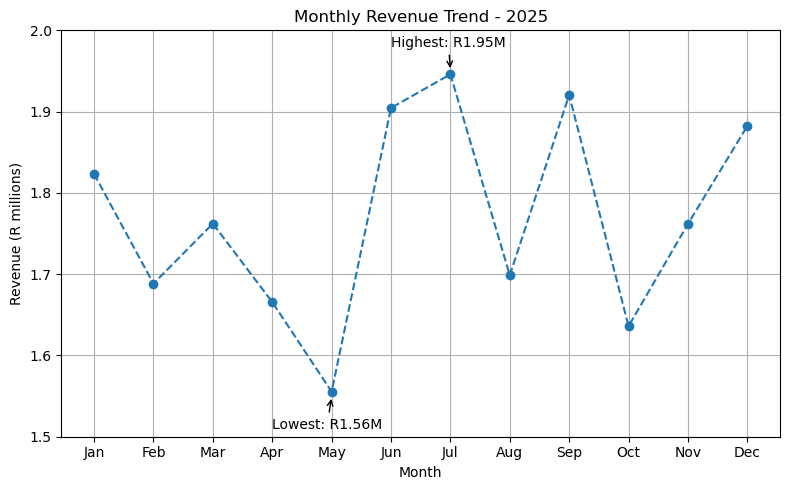

In [79]:
# Monthly revenue trend
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(revenue["Month"], revenue["Revenue_Millions"], marker="o", linestyle="--")
ax.set_title("Monthly Revenue Trend - 2025")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (R millions)")
ax.set_xticks(range(1, 13), months)
ax.set_ylim(1.5,2)
ax.grid()
ax.annotate("Highest: R1.95M", xy=(7, 1.95), xytext=(6, 1.98), arrowprops=dict(arrowstyle="->"))
ax.annotate("Lowest: R1.56M", xy=(5, 1.55), xytext=(4, 1.51), arrowprops=dict(arrowstyle="->"))
plt.tight_layout()
plt.show()


Monthly revenue fluctuated throughout 2025, reaching its highest level in July at approximately R1.95 million and its lowest in May at approximately R1.56 million. July's revenue was about 25.1% higher than May's. Further analysis showed that July recorded more orders and units sold, alongside a moderately higher average order value.

In [69]:
sales_channel["Revenue_Millions"] = sales_channel["Total_Revenue"] / 1_000_000

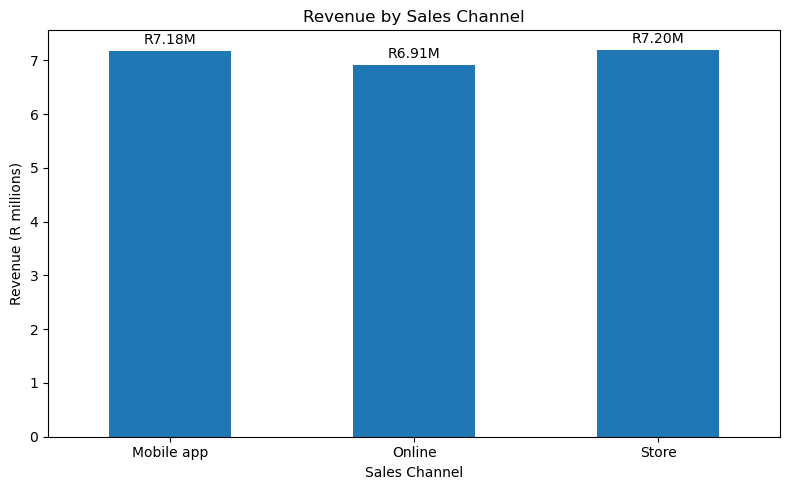

In [70]:
# Revenue by sales channel
fig, ax = plt.subplots(figsize=(8, 5))
sales_channel.plot(x="Sales_Channel", y="Revenue_Millions", kind="bar", ax=ax, legend=False)
ax.bar_label(ax.containers[0], padding=3, labels=[f"R{v.get_height():,.2f}M" for v in ax.containers[0]])
ax.set_title("Revenue by Sales Channel")
ax.set_xlabel("Sales Channel")
ax.set_ylabel("Revenue (R millions)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


Store generated the highest revenue at approximately R7.20M, narrowly exceeding Mobile app at R7.18M, while Online generated R6.91M.

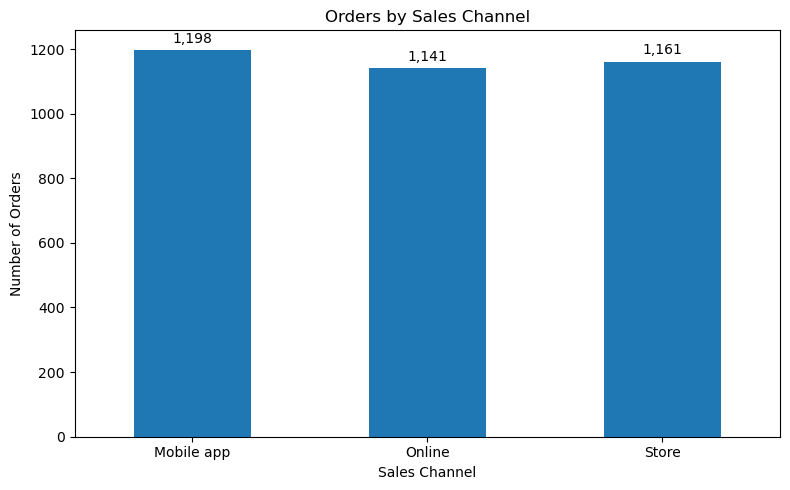

In [71]:
# Orders by sales channel
fig, ax = plt.subplots(figsize=(8, 5))
sales_channel.plot(x="Sales_Channel", y="Number_of_Orders", kind="bar", ax=ax, legend=False)
ax.bar_label(ax.containers[0], padding=3, labels=[f"{v.get_height():,.0f}" for v in ax.containers[0]])
ax.set_title("Orders by Sales Channel")
ax.set_xlabel("Sales Channel")
ax.set_ylabel("Number of Orders")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


Mobile app recorded the highest number of orders (1,198), but Store generated the highest revenue (R7.20M). This indicates that Store transactions tend to have greater monetary value, while Mobile app leads in transaction frequency.

In [72]:
revenue_category = df.groupby("Category").agg(Total_Revenue=("REVENUE","sum")).reset_index()
revenue_category["Revenue_Millions"] = revenue_category["Total_Revenue"] / 1_000_000
revenue_category

,Category,Total_Revenue,Revenue_Millions
0,Appliances,1.987633e+06,1.987633
1,Clothing,1.599649e+06,1.599649
2,Electronics,1.357461e+07,13.574609
3,Furniture,4.118617e+06,4.118617


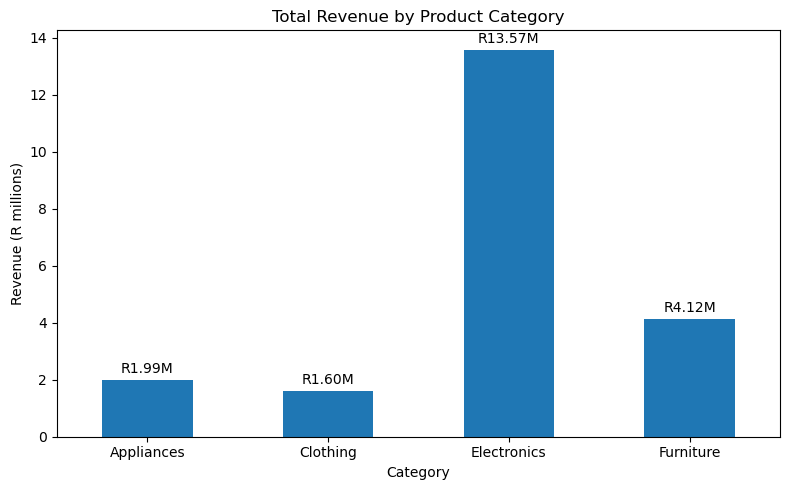

In [73]:
# Total revenue by product category
fig, ax = plt.subplots(figsize=(8, 5))
revenue_category.plot(x="Category", y="Revenue_Millions", kind="bar", ax=ax, legend=False)
ax.bar_label(ax.containers[0], padding=3, labels=[f"R{v.get_height():,.2f}M" for v in ax.containers[0]])
ax.set_title("Total Revenue by Product Category")
ax.set_xlabel("Category")
ax.set_ylabel("Revenue (R millions)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


Electronics was the dominant revenue-generating category, producing approximately R13.57 million—more than three times the R4.12 million generated by Furniture, the second-highest category. Earlier analysis also showed Electronics leading in total quantity sold and number of orders, indicating strength across both sales volume and revenue.

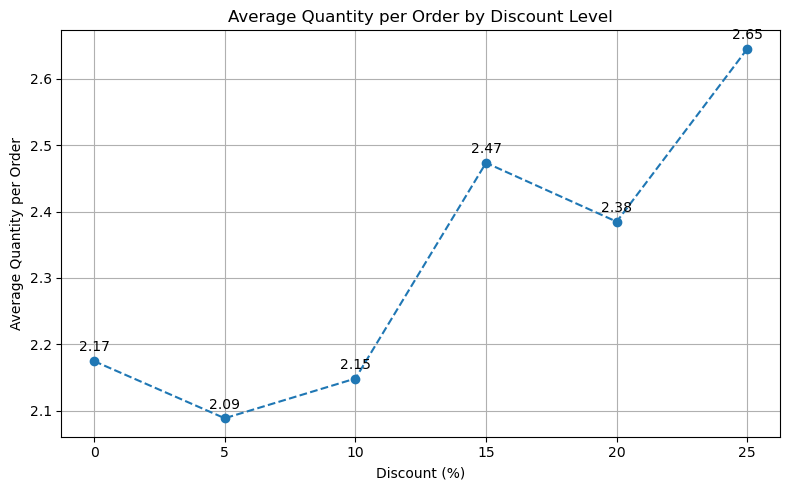

In [74]:
# Average quantity per order by discount level
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(revenue_analysis["Discount"], revenue_analysis["Avg_Quantity_Order"], marker="o", linestyle="--")
for x, y in zip(revenue_analysis["Discount"], revenue_analysis["Avg_Quantity_Order"]):
    ax.annotate(f"{y:.2f}", (x, y), xytext=(0, 7), textcoords="offset points", ha="center")
ax.set_title("Average Quantity per Order by Discount Level")
ax.set_xlabel("Discount (%)")
ax.set_ylabel("Average Quantity per Order")
ax.grid()
plt.tight_layout()
plt.show()


Average quantity per order generally increased at higher discount levels, rising from 2.17 units with no discount to 2.65 units at a 25% discount. However, the relationship was not perfectly consistent, with declines observed at 5% and 20%.

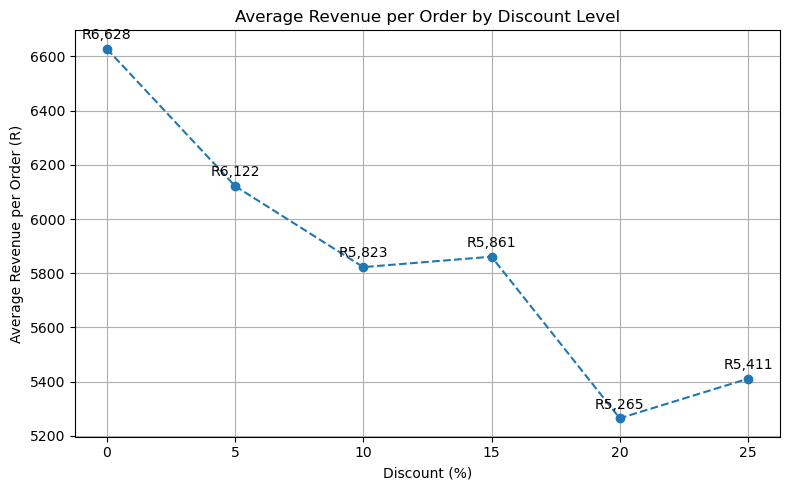

In [75]:
# Average revenue per order by discount level
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(revenue_analysis["Discount"], revenue_analysis["Avg_Revenue_Order"], marker="o", linestyle="--")
for x, y in zip(revenue_analysis["Discount"], revenue_analysis["Avg_Revenue_Order"]):
    ax.annotate(f"R{y:,.0f}", (x, y), xytext=(0, 7), textcoords="offset points", ha="center")
ax.set_title("Average Revenue per Order by Discount Level")
ax.set_xlabel("Discount (%)")
ax.set_ylabel("Average Revenue per Order (R)")
ax.grid()
plt.tight_layout()
plt.show()


Higher discounts were generally associated with larger quantities purchased per order, but this did not translate into higher revenue per transaction. Average quantity increased from 2.17 units at 0% discount to 2.65 units at 25%, while average revenue per order fell from approximately R6,628 to R5,411. This suggests a trade-off between sales volume and revenue per transaction. Product-level analysis further showed that discount performance varies by product, with no single discount level consistently producing the highest average revenue per order.

# Key Findings

- **Electronics was the strongest-performing category**, generating approximately **R13.57 million** in revenue while also leading in total quantity sold and number of orders.
- **Store generated the highest sales-channel revenue** at approximately **R7.20 million**, while **Mobile app recorded the highest number of orders**. Product-level analysis indicated that Store's product mix contributed to its higher average transaction value.
- **July recorded the highest monthly revenue** at approximately **R1.95 million**, while **May recorded the lowest** at approximately **R1.56 million**.
- The **top 10 customers accounted for approximately 6.1% of total revenue**, suggesting that revenue was not heavily concentrated among the highest-value customers.
- Higher discount levels were generally associated with **greater quantities purchased per order**, but **average revenue per order generally declined** as discounts increased.
- Discount performance varied substantially by product. **No single discount level consistently produced the highest observed average revenue per order** across all products.


# Conclusion

The analysis shows that retail performance differs substantially across product categories, sales channels, customers, and discount levels.

Electronics represents the strongest source of revenue in the dataset, while Store and Mobile app demonstrate different strengths: Store generates higher-value transactions, whereas Mobile app processes greater transaction volume.

Discount analysis also reveals an important trade-off. Larger discounts are associated with increased quantities per order, but this does not necessarily translate into greater revenue per transaction. Product-level results further suggest that discount performance differs across products rather than following a single universal pattern.

These results are observational and should not be interpreted as evidence that discounts directly caused changes in purchasing behaviour. Additional data across multiple periods or controlled pricing experiments would be needed to evaluate causal effects.


## Tools and Skills Demonstrated

- Python
- pandas
- NumPy
- Matplotlib
- SQL
- SQLite
- Data cleaning and validation
- Exploratory data analysis
- CTEs and window functions
- Aggregation and customer analysis
- Revenue and pricing analysis
- Data visualization
- Business insight communication
